<a href="https://colab.research.google.com/github/Adi212004/Customer-Segmentation-using-ML/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

cust_trans_rfm = pd.read_csv("Customer_Trans_RFM_Analysis.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cust_trans_rfm.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,...,frequency,monetary,r_quartile,f_quartile,m_quartile,rfm_score,customer_title,Age_Group,detail_cust_title,rank
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,...,3,645.99,2,1,1,211,Bronze,80,Almost Lost Customer,9
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,...,7,4179.11,3,3,4,334,Gold,50,Potential Customer,5
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,...,6,4965.43,2,2,4,224,Silver,50,Loosing Customer,7
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,...,7,3983.97,1,3,3,133,Bronze,70,Almost Lost Customer,9
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,...,10,6646.00,2,4,4,244,Silver,30,Loosing Customer,7


In [ ]:
cust_trans_rfm.columns

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'online_order', 'order_status', 'brand', 'product_line',
       'product_class', 'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date', 'Profit', 'first_name', 'last_name',
       'gender', 'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'owns_car', 'tenure', 'Age', 'recency', 'frequency', 'monetary',
       'r_quartile', 'f_quartile', 'm_quartile', 'rfm_score', 'customer_title',
       'Age_Group', 'detail_cust_title', 'rank'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features
X = cust_trans_rfm[['recency','frequency','monetary']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means
kmeans = KMeans(n_clusters=4, random_state=42)

cust_trans_rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster summary
cust_trans_rfm.groupby('Cluster')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
Cluster,,,
0,148.331492,4.588214,2408.634479
1,39.603799,7.410004,4082.954052
2,30.238322,9.943756,6479.317849
3,37.290688,4.845506,2198.156931


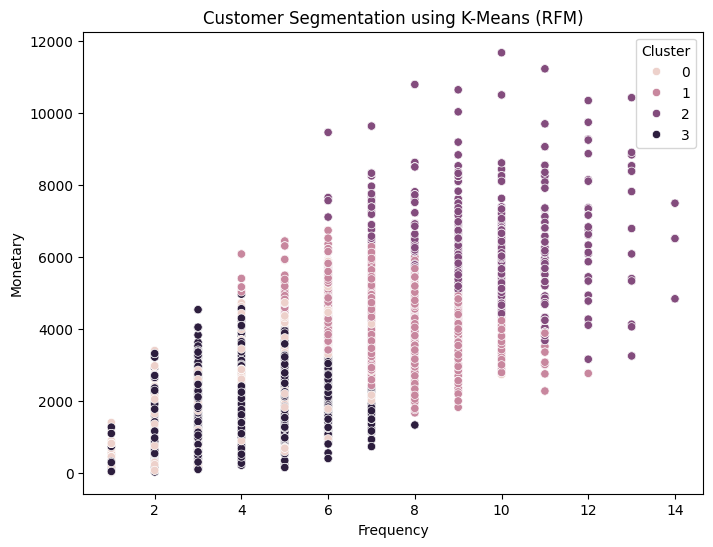

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='frequency',
    y='monetary',
    hue='Cluster',
    data=cust_trans_rfm
)

plt.title("Customer Segmentation using K-Means (RFM)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

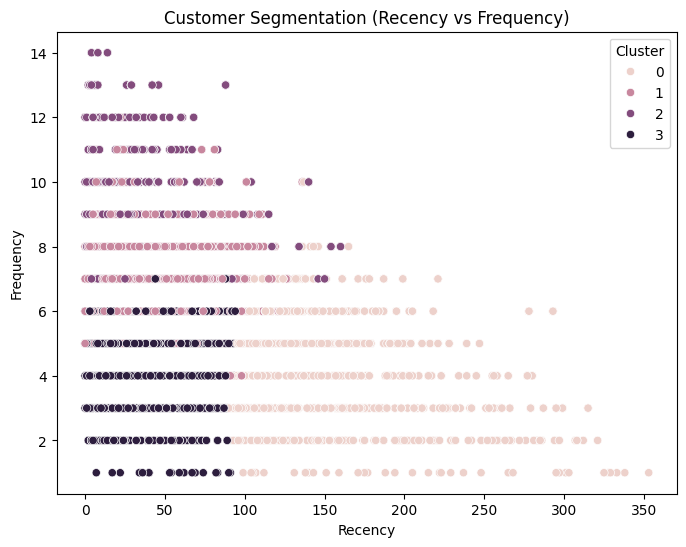

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='recency',
    y='frequency',
    hue='Cluster',
    data=cust_trans_rfm
)

plt.title("Customer Segmentation (Recency vs Frequency)")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

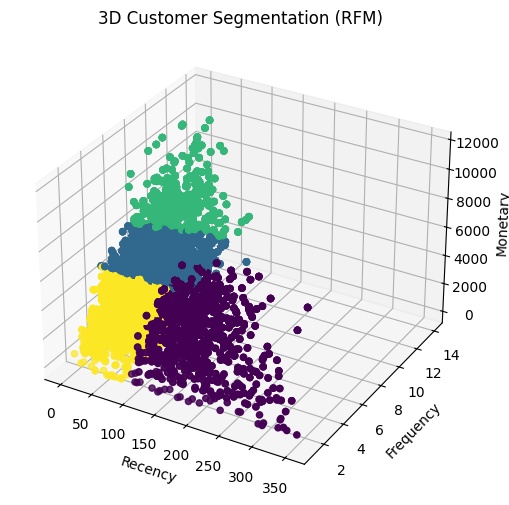

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    cust_trans_rfm['recency'],
    cust_trans_rfm['frequency'],
    cust_trans_rfm['monetary'],
    c=cust_trans_rfm['Cluster']
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title("3D Customer Segmentation (RFM)")

plt.show()